# Klasifikasi Berita Menggunakan Model Word2Vec (Skip-Gram) dan Algoritma Gaussian Naive Bayes


In [21]:
%pip install pandas openpyxl Sastrawi gensim scikit-learn matplotlib seaborn

### Import library

In [22]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


### Membaca dataset Excel

In [23]:
file_path = "berita_detik_200_artikel.xlsx"

df = pd.read_excel(file_path)

print("Dataset berhasil dibaca.")
print("Ukuran dataset:", df.shape)

display(df.head())

Dataset berhasil dibaca.
Ukuran dataset: (200, 3)


,id,isi_berita,label
0,1,Kejuaraan Nasional Gokart 2026 yang berlangsun...,sport
1,2,PT Bank Negara Indonesia (Persero) Tbk atau BN...,sport
2,3,"Pelatih Timnas voli putra Indonesia, Reidel To...",sport
3,4,Kontingen Indonesia bersiap menatap Asian Game...,sport
4,5,Rizki Juniansyah siap menjalani debut di Asian...,sport


### Mengecek dataset

In [24]:
print("Jumlah baris :", len(df))
print("Jumlah kolom :", len(df.columns))

print("\nNama kolom:")
print(df.columns.tolist())

print("\nJumlah label:")
print(df["label"].value_counts())

print("\nData kosong:")
print(df.isnull().sum())

Jumlah baris : 200
Jumlah kolom : 3

Nama kolom:
['id', 'isi_berita', 'label']

Jumlah label:
label
sport      100
finance    100
Name: count, dtype: int64

Data kosong:
id            0
isi_berita    0
label         0
dtype: int64


### Menghapus data kosong

In [25]:
df = df.dropna(subset=["isi_berita", "label"])

print("Setelah menghapus data kosong:")
print("Jumlah data:", len(df))

print("\nData kosong:")
print(df[["isi_berita", "label"]].isnull().sum())

Setelah menghapus data kosong:
Jumlah data: 200

Data kosong:
isi_berita    0
label         0
dtype: int64


kode tersebut bertujuan untuk membersihkan dataset dari nilai kosong (missing values) pada kolom kritis, yaitu isi_berita dan label. Langkah pembersihan ini sangat penting dilakukan sebelum memasuki tahap pemrosesan teks (preprocessing) dan pemodelan, agar tidak timbul error akibat data bernilai NaN/kosong saat diolah oleh library NLP. Melalui fungsi dropna(), baris data yang kehilangan informasi teks atau kategorinya dihapus secara otomatis, dilanjutkan dengan mencetak total data tersisa serta memastikan kembali bahwa jumlah data kosong di kedua kolom tersebut sudah benar-benar nol.

### Melakukan Case Folding

In [26]:
df["case_folding"] = df["isi_berita"].str.lower()

print("Sebelum dilakukan case folding:")
print(df["isi_berita"].iloc[0][:500])

print("\nSetelah dilakukan case folding:")
print(df["case_folding"].iloc[0][:500])

Sebelum dilakukan case folding:
Kejuaraan Nasional Gokart 2026 yang berlangsung dalam enam putaran menghadirkan persaingan ketat hingga seri terakhir. Romy Tahrizi berhasil menjadi Juara Nasional Shifter 150 tahun 2026 bersama Dewa United Motorsport setelah melalui perjuangan sepanjang musim. Kepastian tersebut diraih Romy pada Final Race Round 6 yang berlangsung pada 5-6 September 2026. Sebelumnya, pembalap yang juga berprofesi sebagai Lawyer di Kantor AHHN Lawyers tersebut masih menempati posisi kedua klasemen sementara deng

Setelah dilakukan case folding:
kejuaraan nasional gokart 2026 yang berlangsung dalam enam putaran menghadirkan persaingan ketat hingga seri terakhir. romy tahrizi berhasil menjadi juara nasional shifter 150 tahun 2026 bersama dewa united motorsport setelah melalui perjuangan sepanjang musim. kepastian tersebut diraih romy pada final race round 6 yang berlangsung pada 5-6 september 2026. sebelumnya, pembalap yang juga berprofesi sebagai lawyer di kantor ahhn law

kode tersebut bertujuan untuk melakukan case folding, yaitu mengubah seluruh huruf kapital pada teks di kolom isi_berita menjadi huruf kecil (lowercase). Langkah ini dilakukan agar sistem memperlakukan kata yang sama sebagai satu entitas unik tanpa terpengaruh oleh perbedaan penggunaan huruf besar atau kecil (misalnya, kata "Sepakbola", "SEPAKBOLA", dan "sepakbola" dianggap identik). Kode tersebut kemudian menampilkan perbandingan 500 karakter pertama dari teks berita sebelum dan sesudah proses case folding untuk memastikan bahwa seluruh karakter huruf telah berhasil diseragamkan.

### Menghapus tanda baca

In [27]:
def hapus_tanda_baca(teks):
    return teks.translate(str.maketrans("", "", string.punctuation))

df["tanpa_tanda_baca"] = df["case_folding"].apply(hapus_tanda_baca)

print("Sebelum tanda baca dihapus:")
print(df["case_folding"].iloc[0][:500])

print("\nSetelah tanda baca dihapus:")
print(df["tanpa_tanda_baca"].iloc[0][:500])

Sebelum tanda baca dihapus:
kejuaraan nasional gokart 2026 yang berlangsung dalam enam putaran menghadirkan persaingan ketat hingga seri terakhir. romy tahrizi berhasil menjadi juara nasional shifter 150 tahun 2026 bersama dewa united motorsport setelah melalui perjuangan sepanjang musim. kepastian tersebut diraih romy pada final race round 6 yang berlangsung pada 5-6 september 2026. sebelumnya, pembalap yang juga berprofesi sebagai lawyer di kantor ahhn lawyers tersebut masih menempati posisi kedua klasemen sementara deng

Setelah tanda baca dihapus:
kejuaraan nasional gokart 2026 yang berlangsung dalam enam putaran menghadirkan persaingan ketat hingga seri terakhir romy tahrizi berhasil menjadi juara nasional shifter 150 tahun 2026 bersama dewa united motorsport setelah melalui perjuangan sepanjang musim kepastian tersebut diraih romy pada final race round 6 yang berlangsung pada 56 september 2026 sebelumnya pembalap yang juga berprofesi sebagai lawyer di kantor ahhn lawyers tersebut

kode tersebut bertujuan untuk menghapus seluruh tanda baca (seperti titik, koma, tanda petik, dan simbol lainnya) dari teks berita. Langkah ini penting untuk menghilangkan karakter tak bermakna yang dapat mengganggu analisis teks dan memperbanyak variasi kata secara tak perlu. Dengan fungsi hapus_tanda_baca() yang memanfaatkan string.punctuation, teks hasil case folding dibersihkan sehingga hanya menyisakan kata dan angka, lalu kode menampilkan perbandingan 500 karakter pertama sebelum dan sesudah proses pembersihan untuk memastikan tanda baca telah berhasil dihilangkan.

### Menghapus angka

In [28]:
def hapus_angka(teks):
    return re.sub(r"\d+", "", teks)

df["tanpa_angka"] = df["tanpa_tanda_baca"].apply(hapus_angka)

print("Sebelum angka dihapus:")
print(df["tanpa_tanda_baca"].iloc[0][:500])

print("\nSetelah angka dihapus:")
print(df["tanpa_angka"].iloc[0][:500])

Sebelum angka dihapus:
kejuaraan nasional gokart 2026 yang berlangsung dalam enam putaran menghadirkan persaingan ketat hingga seri terakhir romy tahrizi berhasil menjadi juara nasional shifter 150 tahun 2026 bersama dewa united motorsport setelah melalui perjuangan sepanjang musim kepastian tersebut diraih romy pada final race round 6 yang berlangsung pada 56 september 2026 sebelumnya pembalap yang juga berprofesi sebagai lawyer di kantor ahhn lawyers tersebut masih menempati posisi kedua klasemen sementara dengan se

Setelah angka dihapus:
kejuaraan nasional gokart  yang berlangsung dalam enam putaran menghadirkan persaingan ketat hingga seri terakhir romy tahrizi berhasil menjadi juara nasional shifter  tahun  bersama dewa united motorsport setelah melalui perjuangan sepanjang musim kepastian tersebut diraih romy pada final race round  yang berlangsung pada  september  sebelumnya pembalap yang juga berprofesi sebagai lawyer di kantor ahhn lawyers tersebut masih menempati posisi kedu

kode tersebut bertujuan untuk menghapus seluruh karakter angka dari teks berita menggunakan ekspresi reguler (regular expression r"\d+"). Langkah ini dilakukan karena dalam tugas klasifikasi topik berita umum, karakter angka (seperti tanggal, jumlah, atau nomor) biasanya bersifat sangat spesifik dan tidak memberikan makna kontekstual yang signifikan untuk membedakan kategori berita. Dengan menggunakan fungsi hapus_angka(), teks hasil pembersihan tanda baca diproses sehingga hanya menyisakan kata-kata, lalu kode menampilkan perbandingan 500 karakter pertama sebelum dan sesudah pembersihan untuk memastikan seluruh angka telah berhasil dihilangkan.

### Membersihkan spasi

In [29]:
def bersihkan_spasi(teks):
    return re.sub(r"\s+", " ", teks).strip()

df["clean_text"] = df["tanpa_angka"].apply(bersihkan_spasi)

print(df["clean_text"].iloc[0][:500])

kejuaraan nasional gokart yang berlangsung dalam enam putaran menghadirkan persaingan ketat hingga seri terakhir romy tahrizi berhasil menjadi juara nasional shifter tahun bersama dewa united motorsport setelah melalui perjuangan sepanjang musim kepastian tersebut diraih romy pada final race round yang berlangsung pada september sebelumnya pembalap yang juga berprofesi sebagai lawyer di kantor ahhn lawyers tersebut masih menempati posisi kedua klasemen sementara dengan selisih poin dari pemuncak


kode tersebut bertujuan untuk merapikan dan membersihkan spasi yang tidak teratur pada teks berita menggunakan ekspresi reguler (r"\s+") dan metode .strip(). Langkah ini penting dilakukan setelah proses penghapusan tanda baca dan angka, yang biasanya meninggalkan spasi ganda, spasi berlebih antar kata, atau spasi liar di awal dan akhir kalimat. Dengan fungsi bersihkan_spasi(), teks dipastikan menjadi rapi dengan hanya satu spasi standar sebagai pemisah antar kata, lalu kode menampilkan 500 karakter pertama dari kolom clean_text untuk mengonfirmasi bahwa struktur teks sudah bersih dan siap dilanjutkan ke tahap pemrosesan berikutnya.

### Melakukan Tokenisasi

In [30]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

print("Teks:")
print(df["clean_text"].iloc[0][:300])

print("\nToken:")
print(df["tokens"].iloc[0][:30])

print("\nJumlah token:")
print(len(df["tokens"].iloc[0]))

Teks:
kejuaraan nasional gokart yang berlangsung dalam enam putaran menghadirkan persaingan ketat hingga seri terakhir romy tahrizi berhasil menjadi juara nasional shifter tahun bersama dewa united motorsport setelah melalui perjuangan sepanjang musim kepastian tersebut diraih romy pada final race round y

Token:
['kejuaraan', 'nasional', 'gokart', 'yang', 'berlangsung', 'dalam', 'enam', 'putaran', 'menghadirkan', 'persaingan', 'ketat', 'hingga', 'seri', 'terakhir', 'romy', 'tahrizi', 'berhasil', 'menjadi', 'juara', 'nasional', 'shifter', 'tahun', 'bersama', 'dewa', 'united', 'motorsport', 'setelah', 'melalui', 'perjuangan', 'sepanjang']

Jumlah token:
614


kode tersebut bertujuan untuk melakukan tokenisasi, yaitu memecah string teks berita yang sudah bersih menjadi daftar kata-kata individual (list of tokens) menggunakan fungsi .split(). Langkah ini merupakan pemisahan mendasar dalam Natural Language Processing (NLP) agar setiap kata dapat diakses dan diproses secara terpisah pada tahap-tahap berikutnya, seperti stopword removal, stemming, dan embedding. Kode tersebut kemudian menampilkan perbandingan antara 300 karakter pertama teks utuh, 30 kata/token pertama hasil pemotongan, serta total jumlah token dalam dokumen tersebut untuk memastikan proses pemisahan kata berjalan dengan benar.

### Melakukan Stopword

In [31]:
factory_stopword = StopWordRemoverFactory()
stopwords = set(factory_stopword.get_stop_words())

print("Jumlah stopword:", len(stopwords))
print("\nContoh stopword:")
print(list(stopwords)[:30])

Jumlah stopword: 123

Contoh stopword:
['sementara', 'jika', 'seterusnya', 'seraya', 'terhadap', 'tidak', 'yaitu', 'oh', 'ok', 'daripada', 'oleh', 'harus', 'sekitar', 'untuk', 'pula', 'kah', 'apalagi', 'secara', 'agar', 'yakni', 'hal', 'sesuatu', 'serta', 'dan', 'itulah', 'kembali', 'sebelum', 'dapat', 'melainkan', 'setiap']


kode tersebut bertujuan untuk menyiapkan dan menampilkan daftar kata umum (stopwords) dalam bahasa Indonesia menggunakan library Sastrawi melalui kelas StopWordRemoverFactory. Stopwords adalah kata hubung atau kata tugas yang sering muncul tetapi tidak memiliki makna penting untuk menentukan topik berita (seperti "yang", "di", "ke", "dari", atau "dan"). Langkah ini dilakukan sebagai persiapan sebelum kata-kata tersebut dibuang dari dataset, sehingga model dapat berfokus hanya pada kata-kata bernilai informasi tinggi. Kode tersebut kemudian mencetak total jumlah stopword yang berhasil dimuat serta menampilkan 30 contoh katanya untuk memastikan daftar sudah siap digunakan.

### Menghapus Stopword

In [32]:
def hapus_stopword(tokens):
    return [kata for kata in tokens if kata not in stopwords]

df["tokens_stopword"] = df["tokens"].apply(hapus_stopword)

print("Sebelum dilakukan stopword:")
print(df["tokens"].iloc[0][:40])

print("\nSetelah dilakukan stopword:")
print(df["tokens_stopword"].iloc[0][:40])

Sebelum dilakukan stopword:
['kejuaraan', 'nasional', 'gokart', 'yang', 'berlangsung', 'dalam', 'enam', 'putaran', 'menghadirkan', 'persaingan', 'ketat', 'hingga', 'seri', 'terakhir', 'romy', 'tahrizi', 'berhasil', 'menjadi', 'juara', 'nasional', 'shifter', 'tahun', 'bersama', 'dewa', 'united', 'motorsport', 'setelah', 'melalui', 'perjuangan', 'sepanjang', 'musim', 'kepastian', 'tersebut', 'diraih', 'romy', 'pada', 'final', 'race', 'round', 'yang']

Setelah dilakukan stopword:
['kejuaraan', 'nasional', 'gokart', 'berlangsung', 'enam', 'putaran', 'menghadirkan', 'persaingan', 'ketat', 'hingga', 'seri', 'terakhir', 'romy', 'tahrizi', 'berhasil', 'menjadi', 'juara', 'nasional', 'shifter', 'tahun', 'bersama', 'dewa', 'united', 'motorsport', 'melalui', 'perjuangan', 'sepanjang', 'musim', 'kepastian', 'tersebut', 'diraih', 'romy', 'final', 'race', 'round', 'berlangsung', 'september', 'sebelumnya', 'pembalap', 'berprofesi']


kode tersebut bertujuan untuk menghapus kata-kata umum (stopwords) dari daftar token berita menggunakan fungsi hapus_stopword(). Fungsi ini menyaring setiap kata dalam daftar token dan hanya menyimpam kata yang tidak terdaftar di dalam koleksi stopwords Sastrawi. Langkah ini sangat penting untuk mengurangi kebiasaan (noise) data dan memperkecil ukuran vocabulary, sehingga model hanya berfokus pada kata-kata yang memiliki bobot informasi penting untuk membedakan kategori berita. Kode tersebut kemudian menampilkan perbandingan 40 token pertama sebelum dan sesudah penyaringan untuk memastikan bahwa kata-kata seperti kata hubung atau kata depan telah berhasil dibuang.

### Melakukan Stemmer

In [33]:
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

print("Stemmer berhasil dibuat.")

Stemmer berhasil dibuat.


kode tersebut bertujuan untuk inisialisasi dan pembuatan objek stemmer bahasa Indonesia menggunakan library Sastrawi melalui kelas StemmerFactory. Pembuatan objek ini dilakukan di awal agar siap digunakan pada proses stemming (mengubah kata berimbuhan menjadi kata dasar). Pemisahan langkah ini dari fungsi pemrosesan utama bertujuan untuk efisiensi eksekusi program, kemudian perintah print digunakan untuk mengonfirmasi bahwa pustaka Sastrawi telah berhasil mengunduh seluruh aturan tata bahasa dan siap melakukan proses stemming.

### Melakukan Stemming

In [34]:
def stemming(tokens):
    return [stemmer.stem(kata) for kata in tokens]

df["tokens_stemmed"] = df["tokens_stopword"].apply(stemming)

print("Sebelum dilakukan stemming:")
print(df["tokens_stopword"].iloc[0][:40])

print("\nSetelah dilakukan stemming:")
print(df["tokens_stemmed"].iloc[0][:40])

Sebelum dilakukan stemming:
['kejuaraan', 'nasional', 'gokart', 'berlangsung', 'enam', 'putaran', 'menghadirkan', 'persaingan', 'ketat', 'hingga', 'seri', 'terakhir', 'romy', 'tahrizi', 'berhasil', 'menjadi', 'juara', 'nasional', 'shifter', 'tahun', 'bersama', 'dewa', 'united', 'motorsport', 'melalui', 'perjuangan', 'sepanjang', 'musim', 'kepastian', 'tersebut', 'diraih', 'romy', 'final', 'race', 'round', 'berlangsung', 'september', 'sebelumnya', 'pembalap', 'berprofesi']

Setelah dilakukan stemming:
['juara', 'nasional', 'gokart', 'langsung', 'enam', 'putar', 'hadir', 'saing', 'ketat', 'hingga', 'seri', 'akhir', 'romy', 'tahrizi', 'hasil', 'jadi', 'juara', 'nasional', 'shifter', 'tahun', 'sama', 'dewa', 'united', 'motorsport', 'lalu', 'juang', 'panjang', 'musim', 'pasti', 'sebut', 'raih', 'romy', 'final', 'race', 'round', 'langsung', 'september', 'belum', 'balap', 'profesi']


kode tersebut bertujuan untuk melakukan stemming, yaitu mengubah setiap kata berimbuhan dalam daftar token menjadi kata dasarnya (misalnya, kata "memenangi" menjadi "menang" atau "berita" tetap "berita") menggunakan objek stemmer dari Sastrawi. Langkah ini penting untuk menyeragamkan variasi kata yang memiliki makna dasar sama agar model tidak menganggapnya sebagai kata yang berbeda, sehingga ukuran vocabulary menjadi lebih efisien. Kode tersebut kemudian menampilkan perbandingan 40 token pertama sebelum dan sesudah proses stemming untuk memastikan seluruh imbuhan (awalan, sisipan, akhiran) pada kata telah berhasil dihilangkan.

### Menghitung jumlah kata unik sebelum dilakukan preprocessing

In [35]:
kata_sebelum = []

for tokens in df["tokens"]:
    kata_sebelum.extend(tokens)

unik_sebelum = set(kata_sebelum)

print("Total kata:", len(kata_sebelum))
print("Jumlah kata unik:", len(unik_sebelum))

Total kata: 56820
Jumlah kata unik: 7205


kode tersebut bertujuan untuk menghitung total kata dan jumlah kata unik (vocabulary size) sebelum dilakukan pemrosesan teks (preprocessing seperti stopword removal dan stemming). Kode ini mengumpulkan seluruh token dari kolom tokens ke dalam satu daftar tunggal kata_sebelum, lalu menggunakan fungsi set() untuk menyaring kata-kata yang sama sehingga diperoleh daftar kata yang unik. Informasi ini penting sebagai data acuan (baseline) awal untuk mengukur sejauh mana proses preprocessing nantinya berhasil mereduksi jumlah kata berulang dan efisiensi ukuran vocabulary.

### Menghitung jumlah kata unik setelah dilakukan preprocessing

In [36]:
kata_sesudah = []

for tokens in df["tokens_stemmed"]:
    kata_sesudah.extend(tokens)

unik_sesudah = set(kata_sesudah)

print("Total kata:", len(kata_sesudah))
print("Jumlah kata unik:", len(unik_sesudah))

print("\nPengurangan kata unik:")
print(len(unik_sebelum) - len(unik_sesudah))

Total kata: 43570
Jumlah kata unik: 5257

Pengurangan kata unik:
1948


kode tersebut bertujuan untuk menghitung total kata dan jumlah kata unik (vocabulary size) setelah seluruh tahap preprocessing (case folding, pembersihan teks, stopword removal, dan stemming) selesai dilakukan. Kode ini mengumpulkan seluruh token dari kolom tokens_stemmed ke dalam satu daftar kata_sesudah, lalu menyaring kata uniknya menggunakan fungsi set(). Terakhir, kode menghitung selisih antara unik_sebelum dan unik_sesudah untuk mengevaluasi seberapa banyak variasi kata terbuang/terreduksi, yang membuktikan efisiensi pembersihan data dalam mengecilkan ukuran vocabulary sebelum dimasukkan ke model Word2Vec.

### Melihat hasil preprocessing

In [37]:
df[[
    "isi_berita",
    "case_folding",
    "tanpa_tanda_baca",
    "tanpa_angka",
    "tokens_stopword",
    "tokens_stemmed",
    "label"
]].head(3)

,isi_berita,case_folding,tanpa_tanda_baca,tanpa_angka,tokens_stopword,tokens_stemmed,label
0,Kejuaraan Nasional Gokart 2026 yang berlangsun...,kejuaraan nasional gokart 2026 yang berlangsun...,kejuaraan nasional gokart 2026 yang berlangsun...,kejuaraan nasional gokart yang berlangsung da...,"[kejuaraan, nasional, gokart, berlangsung, ena...","[juara, nasional, gokart, langsung, enam, puta...",sport
1,PT Bank Negara Indonesia (Persero) Tbk atau BN...,pt bank negara indonesia (persero) tbk atau bn...,pt bank negara indonesia persero tbk atau bni ...,pt bank negara indonesia persero tbk atau bni ...,"[pt, bank, negara, indonesia, persero, tbk, bn...","[pt, bank, negara, indonesia, persero, tbk, bn...",sport
2,"Pelatih Timnas voli putra Indonesia, Reidel To...","pelatih timnas voli putra indonesia, reidel to...",pelatih timnas voli putra indonesia reidel toi...,pelatih timnas voli putra indonesia reidel toi...,"[pelatih, timnas, voli, putra, indonesia, reid...","[latih, timnas, voli, putra, indonesia, reidel...",sport


kode tersebut bertujuan untuk menampilkan ringkasan dan perbandingan perubahan data pada 3 baris pertama (top 3 rows) di setiap tahapan preprocessing. Dengan menyandingkan kolom dari teks asli (isi_berita), hasil case folding, pembersihan tanda baca, pembersihan angka, hasil stopword removal, hasil stemming, hingga label kategorinya dalam satu tabel DataFrame, kode ini berfungsi untuk melakukan verifikasi visual (pemeriksaan kualitas data) guna memastikan bahwa seluruh alur transformasi teks telah berjalan secara runut dan benar sebelum melangkah ke tahap ekstraksi fitur Word2Vec.

### Membuat corpus untuk Word2Vec

In [38]:
corpus = df["tokens_stemmed"].tolist()

print("Jumlah dokumen:", len(corpus))
print("\nDokumen pertama:")
print(corpus[0][:50])

Jumlah dokumen: 200

Dokumen pertama:
['juara', 'nasional', 'gokart', 'langsung', 'enam', 'putar', 'hadir', 'saing', 'ketat', 'hingga', 'seri', 'akhir', 'romy', 'tahrizi', 'hasil', 'jadi', 'juara', 'nasional', 'shifter', 'tahun', 'sama', 'dewa', 'united', 'motorsport', 'lalu', 'juang', 'panjang', 'musim', 'pasti', 'sebut', 'raih', 'romy', 'final', 'race', 'round', 'langsung', 'september', 'belum', 'balap', 'profesi', 'lawyer', 'kantor', 'ahhn', 'lawyers', 'sebut', 'tempat', 'posisi', 'dua', 'klasemen', 'selisih']


kode tersebut bertujuan untuk membentuk corpus, yaitu mengubah kumpulan token hasil stemming pada kolom tokens_stemmed dari bentuk pandas Series menjadi struktur data list standar Python (tolist()). Struktur data berbentuk list of lists (daftar kalimat di mana tiap kalimat berisi daftar kata) ini merupakan format input wajib yang dibutuhkan oleh library Gensim untuk melatih model Word2Vec. Kode tersebut kemudian mencetak total jumlah dokumen (200 artikel) dan menampilkan 50 kata pertama dari dokumen pertama untuk memastikan bahwa corpus telah siap dimasukkan ke dalam pemodelan word embedding.

### Word2Vec Skip-Gram

In [39]:
vector_size = 100
window = 5
min_count = 1
epochs = 20

model_w2v = Word2Vec(
    sentences=corpus,
    vector_size=vector_size,
    window=window,
    min_count=min_count,
    sg=1,          # 1 = Skip-Gram
    workers=4,
    epochs=epochs,
    seed=42
)

print("Word2Vec Skip-Gram berhasil dibuat.")
print("Vector size :", vector_size)
print("Window      :", window)
print("Min count   :", min_count)
print("Epoch       :", epochs)
print("Vocabulary  :", len(model_w2v.wv))

Word2Vec Skip-Gram berhasil dibuat.
Vector size : 100
Window      : 5
Min count   : 1
Epoch       : 20
Vocabulary  : 5257


kode tersebut bertujuan untuk membangun dan melatih model word embedding Word2Vec menggunakan arsitektur Skip-Gram (sg=1) berbasis corpus yang telah dibersihkan. Parameter vector_size=100 menentukan bahwa setiap kata dipetakan menjadi vektor berdimensi 100, window=5 menentukan jangkauan kata konteks di sekitar kata target, min_count=1 memastikan seluruh kata unik masuk ke dalam vocabulary, dan epochs=20 mengatur jumlah iterasi pelatihan. Langkah ini krusial untuk mengonversi kata-kata teks menjadi representasi vektor numerik berdimensi kontinu yang mampu menangkap hubungan makna dan konteks semantik antar-kata, sebelum akhirnya kode mencetak ringkasan konfigurasi model beserta jumlah vocabulary yang berhasil dipelajari.

### Melihat vector sebuah kata

In [40]:
kata = "motogp"

if kata in model_w2v.wv:
    print("Vector untuk kata:", kata)
    print(model_w2v.wv[kata])
    print("\nPanjang vector:", len(model_w2v.wv[kata]))
else:
    print("Kata tidak ditemukan.")

Vector untuk kata: motogp
[ 0.14542289 -0.0763043  -0.07525325  0.1836487  -0.07204488 -0.8098037
  0.4136779  -0.35117003 -0.30488342  0.12403167 -0.34514457  0.12099214
  0.7594229   0.3391698  -0.2645965  -0.26865497  0.33087042 -0.61510533
 -0.2168024   0.4011903   0.09869518  0.04118117  0.26700452  0.67569
 -0.03394868  0.19143434 -0.30023763  0.27899572 -0.60583186  0.3340186
 -0.43533012  0.41575763  0.09692323 -0.3974033   0.6915965   0.56397355
 -0.03859675 -0.5688437   0.39161205  0.13474995 -0.0310381  -0.04235988
  0.5090746  -0.34898254  0.49699536  0.03658485  0.5201839  -0.03108499
  0.24071556 -0.23218507 -0.02374775 -0.6175294   0.5343739  -0.0543852
  0.22230253 -0.77792656  0.32458457  0.5719531  -0.9776999   0.41609877
 -0.1809076  -0.04684957  0.02958082 -0.44859278  0.725699   -0.42974094
  0.46764916 -0.24783298 -0.04301067  1.1938409  -0.20256954 -0.50773966
  0.21653865 -0.3904898   0.3874868  -0.47726765 -0.15768987 -0.12864636
 -0.19683261  0.15321742 -0.054

kode tersebut bertujuan untuk memeriksa dan menampilkan bentuk vektor numerik dari suatu kata tertentu (dalam hal ini kata "motogp") yang telah dipelajari oleh model Word2Vec Skip-Gram. Melalui pengkondisian if kata in model_w2v.wv, kode ini terlebih dahulu memastikan apakah kata tersebut masuk ke dalam vocabulary model. Jika ditemukan, kode akan mencetak deretan angka vektor kontinu berukuran 100 dimensi yang mewakili makna kata tersebut, serta mengonfirmasi panjang dimensi vektornya. Langkah ini berguna sebagai verifikasi untuk melihat secara langsung bagaimana suatu kata berhasil dikonversi dari bentuk teks menjadi representasi vektor numerik.

### Melihat kata yang mirip

In [41]:
kata = "balap"

if kata in model_w2v.wv:
    print("Kata yang paling mirip dengan:", kata)
    print(model_w2v.wv.most_similar(kata, topn=10))
else:
    print("Kata tidak ditemukan.")

Kata yang paling mirip dengan: balap
[('kandang', 0.7745506763458252), ('prix', 0.7704567313194275), ('italia', 0.7680105566978455), ('dalligna', 0.760250985622406), ('sprint', 0.7594074010848999), ('tang', 0.7576108574867249), ('buruk', 0.7564852833747864), ('tunggang', 0.7484589219093323), ('motosan', 0.7445095181465149), ('sirkuit', 0.7433331608772278)]


kode tersebut bertujuan untuk mengevaluasi dan menguji kualitas relasi semantik (makna kata) pada model Word2Vec Skip-Gram dengan mencari kata-kata yang paling mirip dengan kata "balap".

Melalui metode most_similar(kata, topn=10), model menghitung tingkat kemiripan vektor (cosine similarity) antar-kata yang ada dalam vocabulary. Hasilnya akan menampilkan 10 kata teratas yang sering muncul dalam konteks serupa dengan kata "balap" (seperti "sirkuit", "sprint", atau "prix") beserta nilai skor kemiripannya. Langkah ini penting untuk membuktikan bahwa model Word2Vec telah berhasil memahami konteks dan hubungan makna kata dalam domain berita secara logis.

### Mengubah setiap berita menjadi vector

In [42]:
def document_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X = np.array([
    document_vector(tokens, model_w2v)
    for tokens in df["tokens_stemmed"]
])

print("Shape X:", X.shape)

Shape X: (200, 100)


kode tersebut bertujuan untuk mengubah setiap artikel berita (dokumen) menjadi satu vektor representasi tunggal menggunakan metode rata-rata vektor kata (Average Word Vector).   Melalui fungsi document_vector(), sistem mengekstraksi vektor dari setiap kata dalam artikel yang ada di vocabulary Word2Vec, lalu menghitung reratanya (np.mean) sehingga menghasilkan satu vektor berdimensi 100 untuk mewakili keseluruhan isi berita. Proses ini diterapkan pada seluruh dokumen di kolom tokens_stemmed untuk membentang matriks fitur $X$ berukuran (200, 100). Langkah ini sangat krusial karena mengonversi data teks menjadi matriks numerik yang siap digunakan sebagai input pada algoritma pembelajaran mesin (Gaussian Naive Bayes).

### Melihat bentuk vector dokumen

In [43]:
print("Vector dokumen pertama:")
print(X[0])

print("\nJumlah fitur:", X.shape[1])

Vector dokumen pertama:
[-0.02999367 -0.15503299 -0.1803959   0.10302281  0.06080508 -0.08216161
 -0.00686909 -0.01206762 -0.07140671  0.01377277 -0.53750676 -0.00515466
  0.04402555  0.26606742  0.07714206 -0.26540497 -0.04652653 -0.19614415
 -0.06330512  0.01407722  0.10465902  0.3646378   0.14331949  0.45790875
  0.2036137   0.24956144 -0.21757358  0.35880864 -0.14246142  0.06658688
 -0.3769368   0.03304863 -0.01851524 -0.00878291  0.2571519  -0.11270835
  0.07468006 -0.42097235  0.29397315  0.33219188  0.2605379  -0.0547271
  0.28535977 -0.20838398  0.26781613  0.1693563   0.21144061  0.17786653
  0.19048975 -0.18541467  0.04345917 -0.5252538  -0.06919884 -0.11093207
 -0.2296547  -0.0987716  -0.03885553  0.14121403 -0.12225182  0.17469592
 -0.1464881   0.22097556 -0.20159692  0.14842373  0.35954893 -0.15250675
  0.19483146 -0.03796836 -0.06759886  0.16681053 -0.22788352 -0.0405478
  0.0498393  -0.15042892  0.00394126 -0.20891295 -0.03611423 -0.12305012
 -0.17214231 -0.06344903 -0.2

kode tersebut bertujuan untuk menampilkan dan memverifikasi representasi vektor dari dokumen/artikel berita pertama yang telah dihasilkan dari proses Average Word Vector.   Melalui X[0], kode mencetak deretan 100 nilai desimal kontinu yang mewakili karakteristik atau fitur dari artikel pertama secara keseluruhan. Selanjutnya, X.shape[1] digunakan untuk memastikan jumlah kolom/fitur pada matriks $X$, yaitu 100 fitur, sesuai dengan konfigurasi vector_size pada Word2Vec. Langkah ini berfungsi sebagai verifikasi akhir untuk memastikan bahwa data teks berita telah sukses ditransformasikan menjadi bentuk numerik berdimensi konstan yang siap diproses oleh model klasifikasi.

### Membuat target label

In [44]:
y = df["label"]

print("Label:")
print(y.value_counts())

print("\nContoh label:")
print(y.head(10).tolist())

Label:
label
sport      100
finance    100
Name: count, dtype: int64

Contoh label:
['sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport']


 kode tersebut bertujuan untuk menyiapkan dan memeriksa variabel target (label/kategori) yang akan diprediksi oleh model klasifikasi.Kode menyimpan kolom label ke dalam variabel $y$, lalu menggunakan y.value_counts() untuk menampilkan distribusi jumlah data pada masing-masing kategori (misalnya 100 berita "sport" dan 100 berita "finance"). Selanjutnya, y.head(10).tolist() mencetak 10 sampel label pertama untuk memastikan data target sudah berformat list yang bersih. Langkah ini penting dilakukan sebelum pembagian data (data splitting) guna memastikan bahwa kelas kategori seimbang (balanced dataset) dan siap dipasangkan dengan matriks fitur $X$.

### Membagi data 160 train dan 40 test

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=40,
    random_state=42,
    stratify=y
)

print("Data training :", X_train.shape)
print("Data testing  :", X_test.shape)

print("\nDistribusi label training:")
print(y_train.value_counts())

print("\nDistribusi label testing:")
print(y_test.value_counts())

Data training : (160, 100)
Data testing  : (40, 100)

Distribusi label training:
label
finance    80
sport      80
Name: count, dtype: int64

Distribusi label testing:
label
finance    20
sport      20
Name: count, dtype: int64


kode tersebut bertujuan untuk membagi dataset menjadi data latih (training set) dan data uji (testing set) menggunakan fungsi train_test_split dari scikit-learn.

Parameter test_size=40 menentukan bahwa 40 sampel berita dialokasikan untuk pengujian, sementara sisanya (160 berita) digunakan untuk pelatihan model. Parameter stratify=y memastikan bahwa proporsi distribusi label pada data latih dan uji tetap seimbang persis dengan dataset asli (masing-masing kategori "sport" dan "finance" terbagi secara merata 50:50). Sementara itu, random_state=42 digunakan agar pembagian data bersifat konsisten (reproducible) setiap kali kode dijalankan. Akhirnya, kode mencetak dimensi matriks serta distribusi label untuk memastikan bahwa pembagian data latih dan data uji sudah seimbang dan siap masuk ke tahap pemodelan.

### Membuat model Gaussian Naive Bayes

In [46]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

print("Model Gaussian Naive Bayes berhasil dilatih.")

Model Gaussian Naive Bayes berhasil dilatih.


kode tersebut bertujuan untuk inisialisasi dan pelatihan model pemelajaran mesin Gaussian Naive Bayes menggunakan data latih.

Kode membuat objek klasifikasi GaussianNB(), lalu memanggil metode .fit(X_train, y_train) untuk melatih model. Pada tahap ini, algoritma memperhitungkan asumsi bahwa fitur-fitur vektor kontinu dari Word2Vec berdistribusi normal (Gaussian) untuk mempelajari pola probabilitas dari masing-masing kategori berita ("sport" dan "finance") berdasarkan matriks fitur data latih. Terakhir, pesan konfirmasi dicetak untuk memastikan proses pelatihan (training) telah selesai dan model siap digunakan untuk memprediksi data uji.

### Prediksi data testing

In [47]:
y_pred = nb_model.predict(X_test)

print("Hasil prediksi:")
print(y_pred)

print("\nLabel sebenarnya:")
print(y_test.values)

Hasil prediksi:
['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'finance' 'sport'
 'finance']

Label sebenarnya:
['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'finance' 'sport'
 'finance']


kode tersebut bertujuan untuk melakukan pengujian dan membandingkan hasil prediksi model terhadap data uji (testing set).

Melalui panggilan nb_model.predict(X_test), model Gaussian Naive Bayes yang telah dilatih mengevaluasi 40 matriks fitur data uji dan menghasilkan array y_pred yang berisi kategori berita hasil prediksi (apakah "sport" atau "finance"). Kode kemudian mencetak array y_pred beserta label asli dari data uji (y_test.values) secara berdampingan. Langkah ini dilakukan untuk verifikasi awal secara kasatmata guna melihat seberapa akurat model dalam memprediksi kelas berita sebelum menghitung metrik evaluasi secara keseluruhan.

### Tabel hasil prediksi

In [48]:
hasil_prediksi = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred
})

hasil_prediksi["Benar/Salah"] = np.where(
    hasil_prediksi["Aktual"] == hasil_prediksi["Prediksi"],
    "Benar",
    "Salah"
)

display(hasil_prediksi)

,Aktual,Prediksi,Benar/Salah
0,finance,finance,Benar
1,sport,sport,Benar
2,sport,sport,Benar
3,sport,sport,Benar
4,finance,finance,Benar
5,sport,sport,Benar
6,finance,finance,Benar
7,sport,sport,Benar
8,sport,sport,Benar
9,finance,finance,Benar


kode tersebut bertujuan untuk membuat tabel perbandingan evaluasi secara mendetail antara nilai aktual dan hasil prediksi pada data uji.

Kode menyatukan label asli (y_test.values) dan label hasil prediksi (y_pred) ke dalam satu DataFrame pandas bernama hasil_prediksi. Menggunakan fungsi np.where, sistem menambahkan kolom penanda "Benar/Salah" yang secara otomatis mengevaluasi apakah prediksi model cocok dengan data sebenarnya. Fungsi display() kemudian menampilkan tabel tersebut secara interaktif di Jupyter Notebook untuk mempermudah analisis dan inspeksi visual terhadap performa prediksi model berita per masing-masing artikel data uji.

### Accuracy

In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100, "%")

Accuracy: 1.0
Accuracy (%): 100.0 %


kode tersebut bertujuan untuk menghitung dan menampilkan tingkat akurasi (accuracy) dari model Gaussian Naive Bayes dalam mengklasifikasikan data uji.

Melalui fungsi accuracy_score(y_test, y_pred) dari library scikit-learn, sistem menghitung persentase rasio antara jumlah prediksi yang benar (baik untuk kelas "sport" maupun "finance") terhadap total keseluruhan sampel data uji (40 artikel). Kode kemudian mencetak nilai akurasi tersebut dalam bentuk desimal serta format persentase (%). Langkah ini merupakan metrik evaluasi utama untuk mengukur sejauh mana efektivitas gabungan metode Word2Vec Skip-Gram dan Gaussian Naive Bayes dalam memprediksi kategori berita secara akurat.

### Precision, Recall, F1-Score

In [50]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

Precision : 1.0
Recall    : 1.0
F1-Score  : 1.0


kode tersebut bertujuan untuk menghitung dan menampilkan metrik evaluasi tingkat lanjut, yaitu Precision, Recall, dan F1-Score dari model Gaussian Naive Bayes.

Menggunakan fungsi precision_score, recall_score, dan f1_score dengan parameter average="weighted", sistem mengukur performa model dengan memperhitungkan proporsi sampel dari masing-masing kelas:

Precision mengukur seberapa tepat model dalam memprediksi suatu kategori berita (meminimalisir kesalahan false positive).

Recall mengukur seberapa banyak artikel berita dari kategori tertentu yang berhasil ditemukan/ditebak oleh model (meminimalisir kesalahan false negative).

F1-Score memberikan nilai keseimbangan (harmonic mean) antara Precision dan Recall.

### Classification Report

In [51]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["finance", "sport"]
    )
)

Classification Report:
              precision    recall  f1-score   support

     finance       1.00      1.00      1.00        20
       sport       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



kode tersebut bertujuan untuk menampilkan laporan evaluasi performa model secara menyeluruh (classification report) untuk setiap kelas kategori berita.

Menggunakan fungsi classification_report() dari scikit-learn, sistem menyajikan rekapitulasi nilai Precision, Recall, dan F1-Score secara terpisah untuk kategori "finance" dan "sport", beserta nilai support (jumlah sampel data uji pada masing-masing kategori). Laporan ini juga menyertakan perhitungan Rata-Rata Makro (Macro Average) dan Rata-Rata Terbobot (Weighted Average) untuk keseluruhan model. Langkah ini sangat membantu untuk melihat secara detail apakah model bekerja seimbang pada kedua kelas berita atau hanya unggul di salah satu kelas saja.

### Confusion Matrix

In [52]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["finance", "sport"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[20  0]
 [ 0 20]]


kode tersebut bertujuan untuk menghitung dan menampilkan Confusion Matrix, yaitu matriks evaluasi berukuran 2x2 yang memetakan performa prediksi model secara mendetail terhadap label aktual pada data uji.

Menggunakan fungsi confusion_matrix() dari scikit-learn dengan spesifikasi labels=["finance", "sport"], sistem membandingkan jumlah prediksi yang benar dan salah berdasarkan urutan kategori tersebut:

True Negative (TN): Jumlah berita finance yang berhasil diprediksi dengan benar sebagai finance (baris 1, kolom 1).

False Positive (FP): Jumlah berita finance yang salah diprediksi sebagai sport (baris 1, kolom 2).

False Negative (FN): Jumlah berita sport yang salah diprediksi sebagai finance (baris 2, kolom 1).

True Positive (TP): Jumlah berita sport yang berhasil diprediksi dengan benar sebagai sport (baris 2, kolom 2).

Langkah ini penting untuk melihat secara kasatmata pola kesalahan (misclassification) yang terjadi pada model, sehingga Anda dapat mengetahui kategori mana yang paling sering tertukar oleh algoritma Gaussian Naive Bayes.

### Visualisasi Confusion Matrix

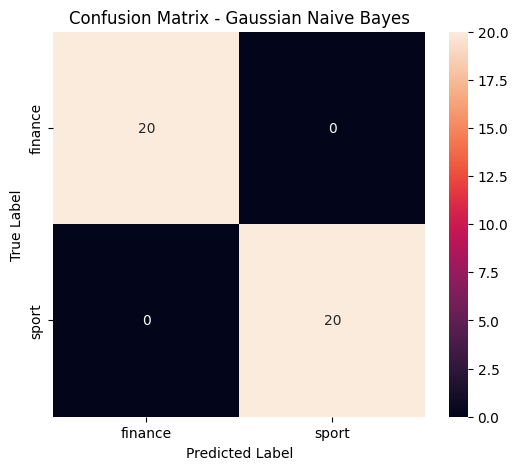

In [53]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["finance", "sport"],
    yticklabels=["finance", "sport"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.show()

kode tersebut bertujuan untuk menampilkan visualisasi Confusion Matrix dalam bentuk diagram peta panas (heatmap) menggunakan library Seaborn dan Matplotlib. Dengan fungsi sns.heatmap(), nilai-nilai numerik pada matriks cm dikonversi menjadi tampilan grafik berwarna lengkap dengan label sumbu (Predicted Label dan True Label) serta angka di setiap selnya (annot=True). Visualisasi ini berfungsi untuk mempermudah analisis intuitif secara visual, sehingga pembaca dapat langsung mengenali sebaran prediksi benar dan salah serta pola misklasifikasi antara kategori "finance" dan "sport" dengan cepat tanpa harus membaca angka mentah array.

In [54]:
hasil_evaluasi = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Nilai": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(hasil_evaluasi)

,Metrik,Nilai
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0


kode tersebut bertujuan untuk merangkum seluruh hasil metrik evaluasi utama model ke dalam satu tabel DataFrame yang rapi dan mudah dibaca.

Dengan menyatukan nilai Accuracy, Precision, Recall, dan F1-Score ke dalam variabel hasil_evaluasi, kode ini menyajikan ringkasan performa akhir model Gaussian Naive Bayes secara terstruktur. Penggunaan fungsi display() mempermudah pembaca untuk melihat, membandingkan, dan mendokumentasikan performa keseluruhan model klasifikasi berita dalam satu tampilan tunggal tanpa harus memeriksa setiap output variabel secara terpisah.

In [55]:
hasil_preprocessing = df[[
    "id",
    "isi_berita",
    "label",
    "clean_text",
    "tokens_stopword",
    "tokens_stemmed"
]]

display(hasil_preprocessing.head(10))

,id,isi_berita,label,clean_text,tokens_stopword,tokens_stemmed
0,1,Kejuaraan Nasional Gokart 2026 yang berlangsun...,sport,kejuaraan nasional gokart yang berlangsung dal...,"[kejuaraan, nasional, gokart, berlangsung, ena...","[juara, nasional, gokart, langsung, enam, puta..."
1,2,PT Bank Negara Indonesia (Persero) Tbk atau BN...,sport,pt bank negara indonesia persero tbk atau bni ...,"[pt, bank, negara, indonesia, persero, tbk, bn...","[pt, bank, negara, indonesia, persero, tbk, bn..."
2,3,"Pelatih Timnas voli putra Indonesia, Reidel To...",sport,pelatih timnas voli putra indonesia reidel toi...,"[pelatih, timnas, voli, putra, indonesia, reid...","[latih, timnas, voli, putra, indonesia, reidel..."
3,4,Kontingen Indonesia bersiap menatap Asian Game...,sport,kontingen indonesia bersiap menatap asian game...,"[kontingen, indonesia, bersiap, menatap, asian...","[kontingen, indonesia, siap, tatap, asi, games..."
4,5,Rizki Juniansyah siap menjalani debut di Asian...,sport,rizki juniansyah siap menjalani debut di asian...,"[rizki, juniansyah, siap, menjalani, debut, as...","[rizki, juniansyah, siap, jalan, debut, asi, g..."
5,6,"Banjir besar melanda Nagoya, Jepang, menjelang...",sport,banjir besar melanda nagoya jepang menjelang a...,"[banjir, besar, melanda, nagoya, jepang, menje...","[banjir, besar, landa, nagoya, jepang, jelang,..."
6,7,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,sport,ketua umum komite olimpiade indonesia koi raja...,"[ketua, umum, komite, olimpiade, indonesia, ko...","[ketua, umum, komite, olimpiade, indonesia, ko..."
7,8,Persaingan titel juara dunia semakin ketat men...,sport,persaingan titel juara dunia semakin ketat men...,"[persaingan, titel, juara, dunia, semakin, ket...","[saing, titel, juara, dunia, makin, ketat, tuj..."
8,9,"Pegokar muda Indonesia, Morgan Holindo, tak pu...",sport,pegokar muda indonesia morgan holindo tak puas...,"[pegokar, muda, indonesia, morgan, holindo, ta...","[gokar, muda, indonesia, morgan, holindo, tak,..."
9,10,Pacuan kuda Indonesia mulai diarahkan menuju p...,sport,pacuan kuda indonesia mulai diarahkan menuju p...,"[pacuan, kuda, indonesia, mulai, diarahkan, me...","[pacu, kuda, indonesia, mulai, arah, tuju, pan..."


kode tersebut bertujuan untuk menyeleksi dan merangkum kolom-kolom utama hasil akhir pemrosesan teks (preprocessing) ke dalam satu DataFrame baru bernama hasil_preprocessing.

Dengan mengambil variabel identifikasi (id), teks asli (isi_berita), kategori (label), teks hasil pembersihan awal (clean_text), token hasil penyaringan kata penting (tokens_stopword), dan token akhir hasil stemming (tokens_stemmed), kode ini menyajikan tampilan struktur data yang terorganisir. Penggunaan fungsi display(hasil_preprocessing.head(10)) menampilkan 10 sampel data pertama untuk verifikasi visual akhir, memastikan bahwa seluruh tahapan transformasi data siap disimpan atau didokumentasikan sebagai dataset bersih sebelum masuk ke tahap ekstrasi fitur dan pemodelan.

In [56]:
 hasil_export = df[[
     "id",
     "isi_berita",
     "label",
     "case_folding",
     "tanpa_tanda_baca",
     "tanpa_angka",
     "clean_text",
     "tokens_stopword",
     "tokens_stemmed"
 ]].copy()

 hasil_export["tokens_stopword"] = hasil_export["tokens_stopword"].apply(
     lambda x: " ".join(x)
 )

 hasil_export["tokens_stemmed"] = hasil_export["tokens_stemmed"].apply(
     lambda x: " ".join(x)
 )

 hasil_export.to_excel(
     "hasil_preprocessing.xlsx",
     index=False
 )

 print("File berhasil disimpan sebagai:")
 print("hasil_preprocessing.xlsx")

File berhasil disimpan sebagai:
hasil_preprocessing.xlsx
